In [1]:
import numpy as np 
import pandas as pd 
import datetime
import re
import os, os.path
import time
from sklearn.model_selection import train_test_split
import random
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

from pprint import pprint
import json

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import ast
import plotly.graph_objs as go
import plotly.express as px


In [2]:
training_data_path = './out/training/'
testing_data_path = './out/testing/'
BUFFER_SIZE = 130
OVERLAP = 30

In [3]:
def get_class_ids(directory):
    # Get a list of all CSV files in the directory
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]

    # Extract unique class names from file names
    class_names = set(f.split('.')[0] for f in csv_files)

    # Create a dictionary mapping class names to new IDs
    class_to_id = {class_name: i for i, class_name in enumerate(sorted(class_names))}

    return class_to_id

In [4]:
class_ids_map = get_class_ids(training_data_path)
class_names = list(class_ids_map.keys())
print(class_ids_map)
print(len(class_ids_map))

{'curl': 0, 'dumbell_row': 1, 'front_raise': 2, 'hammer_curl': 3, 'non_exersice': 4, 'shoulder_press': 5}
6


## Train model

In [5]:
def reshape_function(data, label):
    reshaped_data = tf.reshape(data, [-1, 7, 1])
    return reshaped_data, label


In [6]:
train_set = pd.read_csv('train_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})
test_set = pd.read_csv('test_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})
val_set = pd.read_csv('val_set_' + str(BUFFER_SIZE) + '.csv',converters={'acceleration': eval})


In [7]:
samples = len(train_set['acceleration'][0])
print(samples)


130


In [8]:
# Counting the number of samples for each class
class_counts = train_set['gesture'].value_counts().sort_index()

print(class_counts)

0     312
1     200
2     352
3     240
4    1276
5     308
Name: gesture, dtype: int64


In [9]:
# Counting the number of samples for each class
class_counts = train_set['gesture'].value_counts().sort_index()

total_samples = len(train_set['gesture'])

# Calculating class weights
class_weights = {i: total_samples / (2.0 * count) for i, count in enumerate(class_counts)}

print("Class counts:", {i: int(count) for i, count in enumerate(class_counts)})
print("Class weights:", class_weights)


Class counts: {0: 312, 1: 200, 2: 352, 3: 240, 4: 1276, 5: 308}
Class weights: {0: 4.3076923076923075, 1: 6.72, 2: 3.8181818181818183, 3: 5.6, 4: 1.0532915360501567, 5: 4.363636363636363}


In [10]:
tensor_train_set = tf.data.Dataset.from_tensor_slices(
    (np.array(train_set['acceleration'].tolist(),dtype=np.float64),
     train_set['gesture'].tolist()))

tensor_test_set = tf.data.Dataset.from_tensor_slices(
    (np.array(test_set['acceleration'].tolist(),dtype=np.float64),
     test_set['gesture'].tolist()))

tensor_val_set = tf.data.Dataset.from_tensor_slices(
    (np.array(val_set['acceleration'].tolist(),dtype=np.float64),
     val_set['gesture'].tolist()))


In [11]:
tensor_train_set_cnn = tensor_train_set.map(reshape_function)
tensor_test_set_cnn = tensor_test_set.map(reshape_function)
tensor_val_set_cnn = tensor_val_set.map(reshape_function)


In [49]:
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(samples, 7, 1)),
    tf.keras.layers.Reshape((samples, 7)),

    # Использование меньшего числа units и добавление регуляризации
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, kernel_regularizer=tf.keras.regularizers.l2(0.00001))),
    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),  # Добавление Dropout
    
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.00001)),  # Добавление плотного слоя
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.00001)),  # Добавление плотного слоя  
    tf.keras.layers.Dense(len(class_ids_map), activation="softmax")
])


In [50]:
#calculate_model_size(lstm_model)
epochs_cnn = 200
batch_size = 8


lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_4 (Reshape)          (None, 130, 7)            0         
_________________________________________________________________
bidirectional_4 (Bidirection (None, 128)               36864     
_________________________________________________________________
batch_normalization_8 (Batch (None, 128)               512       
_________________________________________________________________
dropout_8 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_12 (Dense)             (None, 32)                4128      
_________________________________________________________________
batch_normalization_9 (Batch (None, 32)                128       
_________________________________________________________________
dropout_9 (Dropout)          (None, 32)               

In [14]:
tensor_train_set_cnn = tensor_train_set_cnn.batch(batch_size).repeat()
tensor_test_set_cnn = tensor_test_set_cnn.batch(batch_size)
tensor_val_set_cnn = tensor_val_set_cnn.batch(batch_size)


In [51]:
# Определение функции для динамического изменения learning rate
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)

In [52]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=0.00001) 

history = lstm_model.fit(
    tensor_train_set_cnn,
    epochs=epochs_cnn,
    validation_data=tensor_val_set_cnn,
    steps_per_epoch=300,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr], #lr_scheduler
    ) #validation_steps=int((len(val_set) - 1) / batch_size2 + 1)tf.keras.



Epoch 1/200
300/300 [==============================] - 5s 11ms/step - loss: 6.6319 - accuracy: 0.1183 - val_loss: 1.7978 - val_accuracy: 0.2530
Epoch 2/200
300/300 [==============================] - 3s 9ms/step - loss: 5.8505 - accuracy: 0.1721 - val_loss: 1.6965 - val_accuracy: 0.3021
Epoch 3/200
300/300 [==============================] - 3s 9ms/step - loss: 5.4904 - accuracy: 0.2079 - val_loss: 1.5524 - val_accuracy: 0.3452
Epoch 4/200
300/300 [==============================] - 3s 9ms/step - loss: 5.0947 - accuracy: 0.2242 - val_loss: 1.4372 - val_accuracy: 0.4092
Epoch 5/200
300/300 [==============================] - 3s 9ms/step - loss: 4.9113 - accuracy: 0.2604 - val_loss: 1.3122 - val_accuracy: 0.4658
Epoch 6/200
300/300 [==============================] - 3s 9ms/step - loss: 4.7388 - accuracy: 0.2796 - val_loss: 1.2380 - val_accuracy: 0.5045
Epoch 7/200
300/300 [==============================] - 3s 9ms/step - loss: 4.6258 - accuracy: 0.2996 - val_loss: 1.1806 - val_accuracy: 0.540

Epoch 58/200
300/300 [==============================] - 3s 9ms/step - loss: 1.8091 - accuracy: 0.7350 - val_loss: 0.4749 - val_accuracy: 0.8720
Epoch 59/200
300/300 [==============================] - 3s 9ms/step - loss: 1.7698 - accuracy: 0.7462 - val_loss: 0.4565 - val_accuracy: 0.8780
Epoch 60/200
300/300 [==============================] - 3s 9ms/step - loss: 1.7119 - accuracy: 0.7387 - val_loss: 0.4804 - val_accuracy: 0.8750
Epoch 61/200
300/300 [==============================] - 3s 10ms/step - loss: 1.7863 - accuracy: 0.7362 - val_loss: 0.5467 - val_accuracy: 0.8631
Epoch 62/200
300/300 [==============================] - 3s 10ms/step - loss: 1.6741 - accuracy: 0.7604 - val_loss: 0.4843 - val_accuracy: 0.8780
Epoch 63/200
300/300 [==============================] - 3s 10ms/step - loss: 1.7067 - accuracy: 0.7487 - val_loss: 0.5158 - val_accuracy: 0.8646
Epoch 64/200
300/300 [==============================] - 3s 10ms/step - loss: 1.7005 - accuracy: 0.7525 - val_loss: 0.4594 - val_accur

Epoch 115/200
300/300 [==============================] - 3s 9ms/step - loss: 1.1207 - accuracy: 0.8562 - val_loss: 0.4593 - val_accuracy: 0.9018
Epoch 116/200
300/300 [==============================] - 3s 8ms/step - loss: 1.1451 - accuracy: 0.8375 - val_loss: 0.4781 - val_accuracy: 0.8943
Epoch 117/200
300/300 [==============================] - 3s 9ms/step - loss: 1.1553 - accuracy: 0.8396 - val_loss: 0.4921 - val_accuracy: 0.8943
Epoch 118/200
300/300 [==============================] - 3s 9ms/step - loss: 1.1244 - accuracy: 0.8579 - val_loss: 0.4859 - val_accuracy: 0.8929
Epoch 119/200
300/300 [==============================] - 3s 9ms/step - loss: 1.1010 - accuracy: 0.8471 - val_loss: 0.4864 - val_accuracy: 0.8929
Epoch 120/200
300/300 [==============================] - 3s 8ms/step - loss: 1.1415 - accuracy: 0.8442 - val_loss: 0.4754 - val_accuracy: 0.8958
Epoch 121/200
300/300 [==============================] - 3s 9ms/step - loss: 1.1012 - accuracy: 0.8475 - val_loss: 0.4880 - val_ac

300/300 [==============================] - 3s 10ms/step - loss: 1.0879 - accuracy: 0.8583 - val_loss: 0.4783 - val_accuracy: 0.9018
Epoch 172/200
300/300 [==============================] - 3s 10ms/step - loss: 0.9828 - accuracy: 0.8696 - val_loss: 0.4868 - val_accuracy: 0.9062
Epoch 173/200
300/300 [==============================] - 3s 10ms/step - loss: 0.9862 - accuracy: 0.8700 - val_loss: 0.4991 - val_accuracy: 0.9048
Epoch 174/200
300/300 [==============================] - 3s 10ms/step - loss: 1.0632 - accuracy: 0.8654 - val_loss: 0.4894 - val_accuracy: 0.9018
Epoch 175/200
300/300 [==============================] - 3s 10ms/step - loss: 1.0639 - accuracy: 0.8554 - val_loss: 0.4938 - val_accuracy: 0.9048
Epoch 176/200
300/300 [==============================] - 3s 10ms/step - loss: 1.0157 - accuracy: 0.8625 - val_loss: 0.4787 - val_accuracy: 0.9018
Epoch 177/200
300/300 [==============================] - 3s 10ms/step - loss: 1.0109 - accuracy: 0.8612 - val_loss: 0.4871 - val_accuracy:

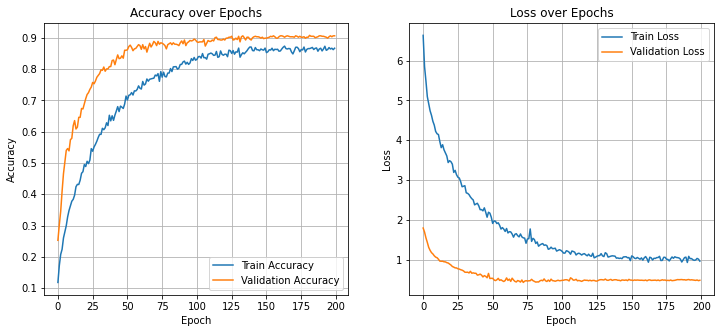

In [53]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
    
    # График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [54]:
loss_cnn, acc_cnn = lstm_model.evaluate(tensor_val_set_cnn)
pred_cnn = np.argmax(lstm_model.predict(tensor_val_set_cnn), axis=1)

id_to_gest = {v: k for k, v in class_ids_map.items()}
y_pred_label = [id_to_gest[i] for i in pred_cnn]

confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(val_set['gesture'].to_numpy()),
    predictions=tf.constant(pred_cnn),
    num_classes=len(class_ids_map))

print(confusion_cnn)
print("Loss {}, Accuracy {}".format(loss_cnn, acc_cnn))

84/84 [==============================] - 0s 5ms/step - loss: 0.4871 - accuracy: 0.9062
tf.Tensor(
[[ 72   2   0   2  18   2]
 [  0  47   0   0   5   0]
 [  1   0  87   0   4   0]
 [  0   0   0  52   0   0]
 [  5   7   0   1 263   4]
 [  0   0   0   0  12  88]], shape=(6, 6), dtype=int32)
Loss 0.48706185817718506, Accuracy 0.90625



Classification Report:
                 precision    recall  f1-score   support

          curl       0.92      0.75      0.83        96
   dumbell_row       0.84      0.90      0.87        52
   front_raise       1.00      0.95      0.97        92
   hammer_curl       0.95      1.00      0.97        52
  non_exersice       0.87      0.94      0.90       280
shoulder_press       0.94      0.88      0.91       100

      accuracy                           0.91       672
     macro avg       0.92      0.90      0.91       672
  weighted avg       0.91      0.91      0.91       672



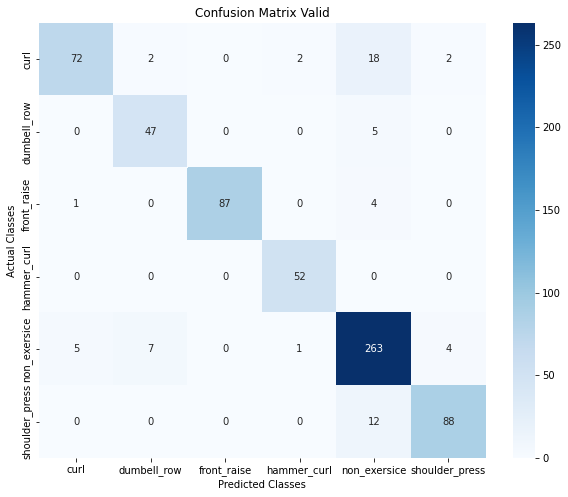

In [55]:
confusion_cnn_np = confusion_cnn.numpy()
true_labels = val_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))

# Visualize Confussion Matrix
plt.figure(figsize=(10, 8))
sb.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Valid')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

In [56]:
loss_cnn, acc_cnn = lstm_model.evaluate(tensor_test_set_cnn)
pred_cnn = np.argmax(lstm_model.predict(tensor_test_set_cnn), axis=1)

id_to_gest = {v: k for k, v in class_ids_map.items()}
y_pred_label = [id_to_gest[i] for i in pred_cnn]

confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(test_set['gesture'].to_numpy()),
    predictions=tf.constant(pred_cnn),
    num_classes=len(class_ids_map))

print(confusion_cnn)
print("Loss {}, Accuracy {}".format(loss_cnn, acc_cnn))

105/105 [==============================] - 1s 5ms/step - loss: 0.3335 - accuracy: 0.9452
tf.Tensor(
[[ 98   1   0   0  16   1]
 [  0  60   0   0   0   0]
 [  0   0 116   0   4   0]
 [  0   0   0  96   0   0]
 [  1  10   1   1 343   0]
 [  1   0   0   0  10  81]], shape=(6, 6), dtype=int32)
Loss 0.33346259593963623, Accuracy 0.9452381134033203



Classification Report:
                 precision    recall  f1-score   support

          curl       0.98      0.84      0.91       116
   dumbell_row       0.85      1.00      0.92        60
   front_raise       0.99      0.97      0.98       120
   hammer_curl       0.99      1.00      0.99        96
  non_exersice       0.92      0.96      0.94       356
shoulder_press       0.99      0.88      0.93        92

      accuracy                           0.95       840
     macro avg       0.95      0.94      0.94       840
  weighted avg       0.95      0.95      0.95       840



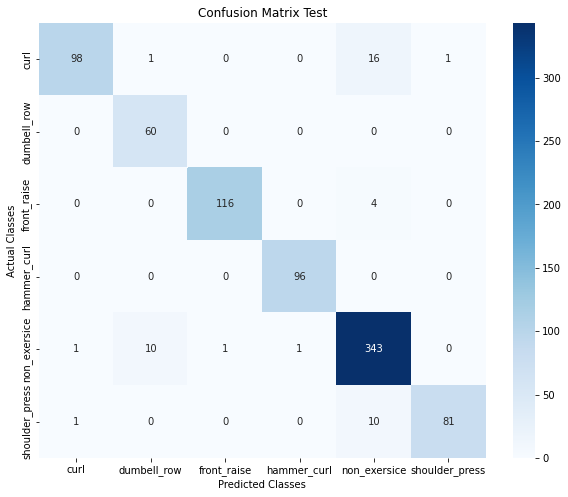

In [57]:
confusion_cnn_np = confusion_cnn.numpy()
true_labels = test_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))
# Визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
sb.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Test')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

## Save and Export Models

In [58]:
MODEL_PREFIX = 'test'
DATE = "07.06.2024"
MODEL_NAME = 'lstm_model_overlap'
TFLITE_MODEL = MODEL_NAME + str(BUFFER_SIZE) + '_' + DATE + ".tflite"
MODEL_NAME =  MODEL_NAME + '_' + str(BUFFER_SIZE) + '_' + DATE
KERAS_MODEL = MODEL_NAME + ".h5"
TFLITE_MODEL = MODEL_NAME + ".tflite"


In [59]:
lstm_model.save(KERAS_MODEL) 


In [62]:
converter = tf.lite.TFLiteConverter.from_keras_model(lstm_model)
lstm_tflite_model = converter.convert()

open(TFLITE_MODEL, "wb").write(lstm_tflite_model)


INFO:tensorflow:Assets written to: /tmp/tmpwz49gvel/assets


INFO:tensorflow:Assets written to: /tmp/tmpwz49gvel/assets


221580

## Export config


In [64]:
'''
Current config for inference
{
    "model_path": "../models/test.tflite",
    "means": [0.3981, 0.4978, 0.2766, 0.6055, 0.2624, -0.0003, 0.2684],
    "std_devs": [0.8194, 0.557, 0.5193, 0.2391, 0.3964, 0.3843, 0.3613],
    "buffer_size": 910,
    "class_names": ["curl", "front_raise", "shoulder_press", "non_exersice", "hammer_curl"],
    "comments": "CNN plus hammer_curl clas"
}
'''

# Load the JSON file into a Python dictionary
with open('test.json') as f:
    config = json.load(f)

pprint(config)
print('-------------')
config["class_names"] = list(class_ids_map.keys())
config["buffer_size"] = BUFFER_SIZE * 7
config["comments"] = "Training pipeline automatization"
config["model_path"] = '../models/' + TFLITE_MODEL

pprint(config)

# Save the updated dictionary back to the JSON file
with open('test.json', 'w+') as f:
    json.dump(config, f)

{'buffer_size': 910,
 'class_names': ['curl',
                 'dumbell_row',
                 'front_raise',
                 'hammer_curl',
                 'non_exersice',
                 'shoulder_press'],
 'comments': 'Training pipeline automatization',
 'means': [0.4352, 0.4944, 0.2427, 0.6037, 0.2698, -0.0446, 0.2435],
 'model_path': '../models/cnn_model_130_04.06.2024.tflite',
 'std_devs': [0.8207, 0.5374, 0.5228, 0.2363, 0.3942, 0.3969, 0.3643]}
-------------
{'buffer_size': 910,
 'class_names': ['curl',
                 'dumbell_row',
                 'front_raise',
                 'hammer_curl',
                 'non_exersice',
                 'shoulder_press'],
 'comments': 'Training pipeline automatization',
 'means': [0.4352, 0.4944, 0.2427, 0.6037, 0.2698, -0.0446, 0.2435],
 'model_path': '../models/lstm_model_overlap_130_07.06.2024.tflite',
 'std_devs': [0.8207, 0.5374, 0.5228, 0.2363, 0.3942, 0.3969, 0.3643]}


## Test metrics

In [65]:
import tensorflow as tf
import numpy as np

# Step 1: Load the TFLite model
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

# Step 2: Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Function for TFLite model inference
def tflite_predict(interpreter, input_data):
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

# Step 3: Prepare data
# Assuming tensor_val_set_cnn is a validation dataset in the form of a TensorFlow Dataset
val_data = [x for x in tensor_test_set_cnn.as_numpy_iterator()]

# Initialize lists for images and labels
val_images = []
val_labels = []

# Extract images and labels from the dataset
for sequence in val_data:
    images, labels = sequence
    val_images.extend(images)
    val_labels.extend(labels)

val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Step 4: Inference and metrics calculation
predictions = []
for image in val_images:
    input_data = np.expand_dims(image, axis=0).astype(np.float32)
    output_data = tflite_predict(interpreter, input_data)
    predictions.append(np.argmax(output_data, axis=1)[0])

# Convert predictions to class labels
id_to_gest = {v: k for k, v in class_ids_map.items()}
y_pred_label = [id_to_gest[i] for i in predictions]

# Build confusion matrix
confusion_cnn = tf.math.confusion_matrix(
    labels=tf.constant(val_labels),
    predictions=tf.constant(predictions),
    num_classes=len(class_ids_map))

print(confusion_cnn)

# Calculate accuracy
accuracy = np.mean(np.array(predictions) == val_labels)

print("Accuracy {}".format(accuracy))


tf.Tensor(
[[ 98   1   0   0  16   1]
 [  0  60   0   0   0   0]
 [  0   0 116   0   4   0]
 [  0   0   0  96   0   0]
 [  1  10   1   1 343   0]
 [  1   0   0   0  10  81]], shape=(6, 6), dtype=int32)
Accuracy 0.9452380952380952



Classification Report:
                 precision    recall  f1-score   support

          curl       0.98      0.84      0.91       116
   dumbell_row       0.85      1.00      0.92        60
   front_raise       0.99      0.97      0.98       120
   hammer_curl       0.99      1.00      0.99        96
  non_exersice       0.92      0.96      0.94       356
shoulder_press       0.99      0.88      0.93        92

      accuracy                           0.95       840
     macro avg       0.95      0.94      0.94       840
  weighted avg       0.95      0.95      0.95       840



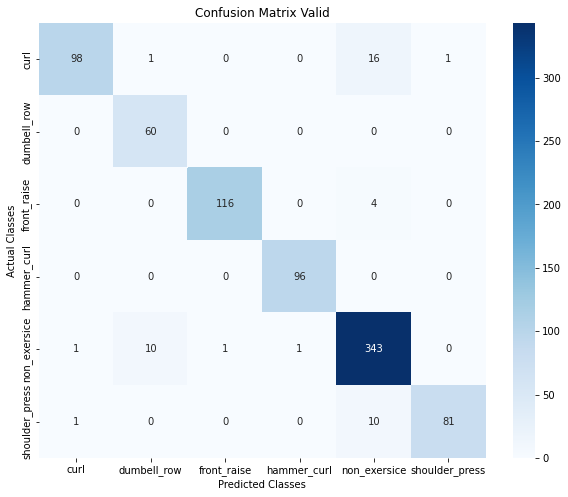

In [66]:
confusion_cnn_np = confusion_cnn.numpy()
true_labels = test_set['gesture'].to_numpy()
true_labels = [id_to_gest[i] for i in true_labels]
print('\nClassification Report:\n', classification_report(true_labels, y_pred_label))

# Visualize Confussion Matrix
plt.figure(figsize=(10, 8))
sb.heatmap(confusion_cnn_np, annot=True, fmt="d", cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix Valid')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()